# [Hands-On] Mastering LLaMA 1: A Complete Walkthrough from Scratch

- Author: Sangkeun Jung (hugmanskj@gmail.com)

> Educational Purpose

**Copyright**: All rights reserved

---

### Overview

This hands-on tutorial is designed for those who want to fully understand and master the LLaMA 1 architecture by building it from scratch. We'll break down every component of the model, covering the theory and practical implementation details, to provide a comprehensive guide from the very basics to the final construction.

Throughout this walkthrough, you will:
- Dive deep into the foundational concepts behind LLaMA 1, such as multi-head attention, feed-forward networks, and the SwiGLU activation function.
- Implement advanced techniques like Rotary Position Embedding (RoPE) and RMSNorm, which optimize performance and efficiency in large models.
- Explore LLaMA's key improvements over traditional transformer models, including how it achieves better scalability and efficiency.
- Verify the correctness of your custom implementation by comparing it to Hugging Face’s official LLaMA 1 model at a high-precision level.

By the end of this tutorial, you'll have a complete understanding of LLaMA 1’s architecture and how to implement it from scratch, making it a powerful resource for both learners and professionals looking to deepen their knowledge of large-scale language models.

---

We begin by implementing essential utility functions, such as data loading, model initialization, and training helper functions. These components will be reused across different experimental setups for consistency and efficiency.

In [45]:
## Importing Libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd

## Hyperparameters and Configuration

In [46]:
# Modified hyperparameters
SEQUENCE_LENGTH = 64

EMBEDDING_DIM = 256
HIDDEN_DIM = 256

BATCH_SIZE = 512
EPOCHS = 1
LEARNING_RATE = 0.001
PRINT_EVERY = 1000
VALIDATION_SPLIT = 0.1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Data Preparation

We are using the TinyShakespeare dataset, a small character-level text corpus consisting of a subset of Shakespeare's plays. It's often used for testing sequence models, as it includes a rich set of vocabulary and provides a challenging task for next-character prediction.

In [47]:
## Utility Functions

def load_data(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        return f.read()

def create_char_mappings(text):
    chars = sorted(list(set(text)))
    char_to_idx = {ch: i for i, ch in enumerate(chars)}
    idx_to_char = {i: ch for i, ch in enumerate(chars)}
    return chars, char_to_idx, idx_to_char

## Dataset

In [ ]:
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=19zosLuU0z4MxIMKbGVYEGlg52QyfbTIy' -O input.txt

--2025-11-06 19:27:55--  https://drive.google.com/uc?export=download&id=19zosLuU0z4MxIMKbGVYEGlg52QyfbTIy
Resolving drive.google.com (drive.google.com)... 74.125.130.138, 74.125.130.100, 74.125.130.101, ...
Connecting to drive.google.com (drive.google.com)|74.125.130.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=19zosLuU0z4MxIMKbGVYEGlg52QyfbTIy&export=download [following]
--2025-11-06 19:27:56--  https://drive.usercontent.google.com/download?id=19zosLuU0z4MxIMKbGVYEGlg52QyfbTIy&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.200.132, 2404:6800:4003:c00::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.200.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [application/octet-stream]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    i

In [ ]:
class CharDataset(Dataset):
    def __init__(self, text, seq_length, char_to_idx):
        self.text = text
        self.seq_length = seq_length
        self.char_to_idx = char_to_idx

    def __len__(self):
        return len(self.text) - self.seq_length

    def __getitem__(self, idx):
        x = [self.char_to_idx[ch] for ch in self.text[idx:idx+self.seq_length]]
        y = [self.char_to_idx[ch] for ch in self.text[idx+1:idx+self.seq_length+1]]
        return torch.tensor(x), torch.tensor(y)

In autoregressive modeling, each input sequence predicts the next token. For this dataset, the input is a sequence of characters from the text, and the target is the same sequence shifted by one character. This technique allows the model to learn sequential dependencies within the text.

In [ ]:
def prepare_data(text, seq_length, batch_size, val_split):
    chars, char_to_idx, idx_to_char = create_char_mappings(text)

    # Split data into train and validation
    val_size = int(len(text) * val_split)
    train_text, val_text = text[:-val_size], text[-val_size:]

    train_dataset = CharDataset(train_text, seq_length, char_to_idx)
    val_dataset = CharDataset(val_text, seq_length, char_to_idx)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, chars, char_to_idx, idx_to_char

In [ ]:
# Load the data
text = load_data('input.txt')
train_loader, val_loader, chars, char_to_idx, idx_to_char = prepare_data(text, SEQUENCE_LENGTH, BATCH_SIZE, VALIDATION_SPLIT)
vocab_size = len(chars)

print(f"Total characters: {len(text)}")
print(f"Vocabulary size: {vocab_size}")
print(f"Train dataset size: {len(train_loader.dataset)}")
print(f"Validation dataset size: {len(val_loader.dataset)}")

Total characters: 1115394
Vocabulary size: 65
Train dataset size: 1003791
Validation dataset size: 111475


## Data Visualization

In [ ]:
# Function to convert index sequence to character sequence
def indices_to_text(indices, idx_to_char):
    return ''.join([idx_to_char[idx.item()] for idx in indices])

# Get a batch of data
dataiter = iter(train_loader)
batch_x, batch_y = next(dataiter)

print(f"Input shape: {batch_x.shape}")
print(f"Target shape: {batch_y.shape}")

# Print a few samples from the batch
num_samples = 3
for i in range(num_samples):
    print(f"Sample {i+1}: ------------------------------" )
    print("Input sequence :", indices_to_text(batch_x[i], idx_to_char).replace('\n',''))
    print("Target sequence:", indices_to_text(batch_y[i], idx_to_char).replace('\n',''))
    print()


Input shape: torch.Size([512, 64])
Target shape: torch.Size([512, 64])
Sample 1: ------------------------------
Input sequence : e, and fret, that I may sing and dance.Thou wouldst be fee'd, I
Target sequence: , and fret, that I may sing and dance.Thou wouldst be fee'd, I 

Sample 2: ------------------------------
Input sequence :  be withstood:Give me his gage: lions make leopards tame.THOM
Target sequence: be withstood:Give me his gage: lions make leopards tame.THOMA

Sample 3: ------------------------------
Input sequence : NENIUS:Repent what you have spoke.CORIOLANUS:For them! I can
Target sequence: ENIUS:Repent what you have spoke.CORIOLANUS:For them! I cann



## Training Function

In [ ]:
def train(model, dataloader, criterion, optimizer, device, epoch, step, log_interval=10):
    model.train()
    losses = []

    for batch, (x, y) in enumerate(dataloader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output, _ = model(x)
        loss = criterion(output.view(-1, output.size(-1)), y.view(-1))
        loss.backward()
        optimizer.step()

        step += 1
        losses.append((step, epoch, loss.item()))

        if (batch + 1) % log_interval == 0:
            print(f'Epoch {epoch}, Step {step}, Batch {batch+1}/{len(dataloader)}, Loss: {loss.item():.4f}')

    return losses, step

In [ ]:
def validate(model, dataloader, criterion, device, epoch, step):
    model.eval()
    losses = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            output, _ = model(x)
            loss = criterion(output.view(-1, output.size(-1)), y.view(-1))
            losses.append((step, epoch, loss.item()))

    return losses

## Generation Function

In [ ]:
def generate(model, char_to_idx, idx_to_char, start_char, max_length, device):
    model.eval()
    hidden = None
    current_char = start_char
    generated_text = current_char

    for _ in range(max_length):
        x = torch.tensor([[char_to_idx[current_char]]]).to(device)
        output, hidden = model(x, hidden)
        probs = torch.softmax(output[0, -1], dim=0)
        next_char_idx = torch.multinomial(probs, 1).item()
        current_char = idx_to_char[next_char_idx]
        generated_text += current_char

    return generated_text


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, log_interval=10):
    all_train_losses = []
    all_val_losses = []
    step = 0

    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs}")
        epoch_start_time = time.time()

        # Training phase
        epoch_train_losses, step = train(model, train_loader, criterion, optimizer, device, epoch, step, log_interval)
        all_train_losses.extend(epoch_train_losses)

        # Validation phase
        epoch_val_losses = validate(model, val_loader, criterion, device, epoch, step)
        all_val_losses.extend(epoch_val_losses)

        epoch_time = time.time() - epoch_start_time
        print(f'Epoch {epoch}/{epochs}, '
              f'Train Loss: {epoch_train_losses[-1][2]:.4f}, '
              f'Val Loss: {epoch_val_losses[-1][2]:.4f}, '
              f'Epoch Time: {epoch_time:.2f}s')

    # Create DataFrames after all epochs
    train_losses_df = pd.DataFrame(all_train_losses, columns=['step', 'epoch', 'loss_value'])
    val_losses_df = pd.DataFrame(all_val_losses, columns=['step', 'epoch', 'loss_value'])

    return model, train_losses_df, val_losses_df

In [ ]:
def generate_text(model, char_to_idx, idx_to_char, start_text, device, max_length=500):
    model.eval()
    current_text = start_text
    hidden = None

    with torch.no_grad():
        for _ in range(max_length):
            x = torch.tensor([[char_to_idx[ch] for ch in current_text[-SEQUENCE_LENGTH:]]]).to(device)
            output, hidden = model(x, hidden)
            probs = torch.softmax(output[0, -1], dim=0)
            next_char_idx = torch.multinomial(probs, 1).item()
            next_char = idx_to_char[next_char_idx]
            current_text += next_char

    return current_text

In [ ]:
# Utiltiy functions

# Dictionary to store the losses from different models/configurations
loss_comparison_dict = {}

# Function to add and store losses from different models
def add_loss_to_comparison(model_name, train_losses_df, val_losses_df):
    """
    Adds training and validation losses from a model to the comparison dictionary.

    Args:
    - model_name (str): A name to identify the model (e.g., 'LSTM', 'LSTM with RMSNorm')
    - train_losses_df (DataFrame): DataFrame containing the training losses.
    - val_losses_df (DataFrame): DataFrame containing the validation losses.
    """
    loss_comparison_dict[model_name] = {
        'train': train_losses_df,
        'val': val_losses_df
    }

In [ ]:
# Function to plot loss curves
def plot_loss(train_losses_df, val_losses_df):
    plt.figure(figsize=(10, 5))

    # Plot training losses
    for epoch in train_losses_df['epoch'].unique():
        epoch_train_losses = train_losses_df[train_losses_df['epoch'] == epoch]
        plt.plot(epoch_train_losses['step'], epoch_train_losses['loss_value'],
                 color='blue', alpha=0.3)

    # scatter training loss at the end of each epoch
    last_train_losses = train_losses_df.groupby('epoch').last().reset_index()
    plt.scatter(last_train_losses['step'], last_train_losses['loss_value'],
                color='blue')

    # Plot and scatter validation loss at the end of each epoch
    last_val_losses = val_losses_df.groupby('epoch').last().reset_index()
    plt.plot(last_val_losses['step'], last_val_losses['loss_value'],
             color='orange', label='Validation Loss')
    plt.scatter(last_val_losses['step'], last_val_losses['loss_value'],
                color='orange')

    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Function to print final loss values
def print_final_losses(train_losses_df, val_losses_df):
    print("Final Training Loss:", train_losses_df.groupby('epoch')['loss_value'].last().iloc[-1])
    print("Final Validation Loss:", val_losses_df.groupby('epoch')['loss_value'].last().iloc[-1])

In [ ]:
# Function to plot loss curves for multiple models stored in loss_comparison_dict
def plot_loss_comparisons():
    """
    Plots the training and validation loss curves for multiple models added to the loss comparison dictionary.
    """
    plt.figure(figsize=(10, 5))

    # Get the last model in the dictionary
    last_model_name = list(loss_comparison_dict.keys())[-1]

    # Loop through each model in the loss dictionary
    for model_name, losses in loss_comparison_dict.items():
        train_losses_df = losses['train']
        val_losses_df = losses['val']

        # Plot training losses for each model
        plt.plot(train_losses_df['step'], train_losses_df['loss_value'],
                 label=f'{model_name}', linestyle='-', alpha=0.7)

        # scatter training loss at the end of each epoch
        last_train_losses = train_losses_df.groupby('epoch').last().reset_index()

        # Scatter normal points for all models
        plt.scatter(last_train_losses['step'], last_train_losses['loss_value'], marker='o', s=50)

        # If this is the last model, highlight the last point with a star (no label in legend)
        if model_name == last_model_name:
            final_step = train_losses_df['step'].iloc[-1]
            final_loss = train_losses_df['loss_value'].iloc[-1]
            plt.scatter(final_step, final_loss, marker='*', s=100, color='red', zorder=5)  # Reduced size to s=100

    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training Loss Comparison')
    plt.legend()  # Legend will only show colors, no final star
    plt.grid(True)
    plt.show()


We have prepared the data and utility functions, let’s implement a simple LSTM-based decoder as a baseline.

This is a foundational model that we’ll use to compare with more advanced architectures like LLaMA. The LSTM decoder will serve as a reference point in terms of performance and complexity.

If you're already familiar with LSTM models, you can skip this section and proceed directly to LLaMA-specific techniques.

## LSTM based Decoder

In [48]:
class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(LSTMDecoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embed = self.embedding(x)
        output, hidden = self.lstm(embed, hidden)
        output = self.fc(output)
        return output, hidden

In [49]:
### Model Initialization
model = LSTMDecoder(vocab_size, EMBEDDING_DIM, HIDDEN_DIM).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [50]:
## Training Loop
trained_model, train_losses_df, val_losses_df = train_model(model, train_loader, val_loader, criterion, optimizer, device, EPOCHS)


Epoch 1/1
Epoch 1, Step 10, Batch 10/1961, Loss: 3.2111
Epoch 1, Step 20, Batch 20/1961, Loss: 2.8542
Epoch 1, Step 30, Batch 30/1961, Loss: 2.6425
Epoch 1, Step 40, Batch 40/1961, Loss: 2.4850
Epoch 1, Step 50, Batch 50/1961, Loss: 2.4018
Epoch 1, Step 60, Batch 60/1961, Loss: 2.3197
Epoch 1, Step 70, Batch 70/1961, Loss: 2.2256
Epoch 1, Step 80, Batch 80/1961, Loss: 2.1854
Epoch 1, Step 90, Batch 90/1961, Loss: 2.1113
Epoch 1, Step 100, Batch 100/1961, Loss: 2.0815
Epoch 1, Step 110, Batch 110/1961, Loss: 2.0448
Epoch 1, Step 120, Batch 120/1961, Loss: 1.9979
Epoch 1, Step 130, Batch 130/1961, Loss: 1.9803
Epoch 1, Step 140, Batch 140/1961, Loss: 1.9509
Epoch 1, Step 150, Batch 150/1961, Loss: 1.9290
Epoch 1, Step 160, Batch 160/1961, Loss: 1.8921
Epoch 1, Step 170, Batch 170/1961, Loss: 1.8903
Epoch 1, Step 180, Batch 180/1961, Loss: 1.8557
Epoch 1, Step 190, Batch 190/1961, Loss: 1.8510
Epoch 1, Step 200, Batch 200/1961, Loss: 1.8279
Epoch 1, Step 210, Batch 210/1961, Loss: 1.8068


In [ ]:
# Text generation using validation data
val_sample, _ = next(iter(val_loader))
start_text = ''.join([idx_to_char[idx.item()] for idx in val_sample[0][:SEQUENCE_LENGTH]])
generated_text = generate_text(trained_model, char_to_idx, idx_to_char, start_text, device)
print(f"Generated text (starting with validation data [{start_text}]):")
print("-"*50)
print(generated_text)

Generated text (starting with validation data [

GREMIO:
Good morrow, neighbour Baptista.

BAPTISTA:
Good morro]):
--------------------------------------------------


GREMIO:
Good morrow, neighbour Baptista.

BAPTISTA:
Good morrow, thy husband by them; for thyself,
From follower in this wounds do strange and do so.
Hear? why, too, do remember away?

POMPEY:
Well, I were temper in well,
At they usurp dead an hand with impite,
And we take the tongue of yourselves: he have heard
The traggtions.

LEONTES:
A my shoulders to my kinnds and sad do.

YORK:
Marry is't,
This may die. This is visentinual tire content thou stir.

BUCKINGHAM:
Pare guests are free that fight with Paulina?

DUKE OF YORK:
My line, the truty
By noble cro


The generated text demonstrates that the model has learned some structure, but the coherence is still lacking.

It can form character strings that resemble English but doesn’t create meaningful sentences. This is typical for early-stage character-level models, which struggle to capture long-term dependencies.

In [51]:
# After training a model (e.g., LSTM without RMSNorm), add its losses
add_loss_to_comparison('LSTM', train_losses_df, val_losses_df)

In [52]:
# Decoder Input/Output Example
sample_input, _ = next(iter(val_loader))
sample_input = sample_input[0].unsqueeze(0).to(device)  # Add batch dimension

trained_model.eval()
with torch.no_grad():
    output, _ = trained_model(sample_input)

print("\nSample Input:")
print(''.join([idx_to_char[idx.item()] for idx in sample_input[0]]))

print("\nModel Output (logits for next character prediction):")
print(output.shape)
print(output[0, 0, :10])  # Print first 10 logits of the first timestep

print("\nPredicted next character:")
predicted_char_idx = torch.argmax(output[0, -1]).item()
print(idx_to_char[predicted_char_idx])


Sample Input:


GREMIO:
Good morrow, neighbour Baptista.

BAPTISTA:
Good morro

Model Output (logits for next character prediction):
torch.Size([1, 64, 65])
tensor([ 4.6994,  0.1052, -4.6588, -3.0977, -2.6919,  0.8609, -3.7924, -1.1466,
        -3.3894, -0.0499], device='cuda:0')

Predicted next character:
w


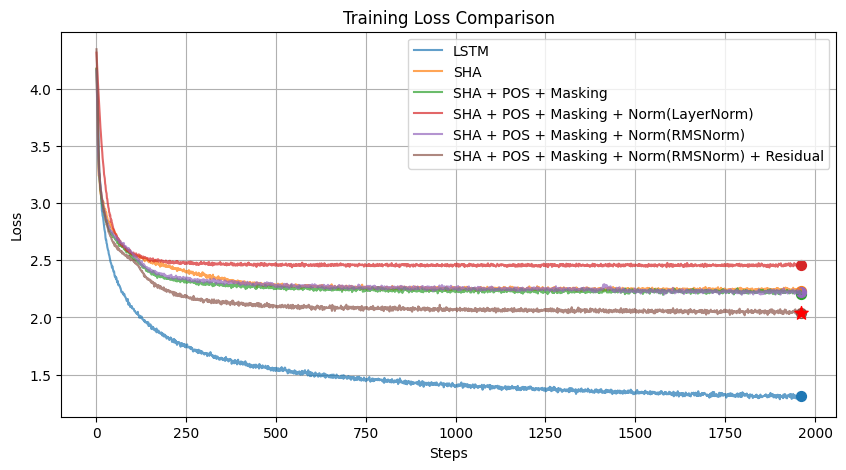

In [53]:
# After you've added multiple models, plot the comparison
plot_loss_comparisons()

We now transition to the core LLaMA components.

From this point, we’ll begin building the essential structures of LLaMA, starting with simple single-head attention-based decoders. We will progressively add complexity to the model, block by block, to achieve a full implementation of LLaMA 1.

Here’s an overview of the steps we’ll follow to build the complete model:

1. **Single-Head Attention Decoder**:
   - We start with a basic single-head attention mechanism to familiarize ourselves with attention layers.
   - This will serve as a foundational block for more complex attention architectures.

2. **Positional Encoding**:
   - To provide the model with an understanding of token order, we will add learnable positional embeddings, helping the model understand sequence order and relationships.

3. **Look-Ahead Masking**:
   - To prevent the model from seeing future tokens during training, we’ll implement look-ahead masking, ensuring proper autoregressive behavior.

4. **Layer Normalization (LayerNorm)**:
   - We’ll introduce LayerNorm, which stabilizes the training process by normalizing the outputs of each layer, improving convergence.

5. **RMSNorm**:
   - Next, we’ll swap out LayerNorm with RMSNorm, a more efficient normalization technique used in LLaMA for larger model scalability and better computational efficiency.

6. **Residual Connections**:
   - Adding residual connections to preserve important information and prevent the degradation of signals as they pass through multiple layers.

7. **Feed-Forward Networks (FFNs)**:
   - We’ll introduce traditional feed-forward layers, followed by LLaMA’s more advanced SwiGLU activation-based feed-forward network, which allows for efficient representation mixing.

8. **Rotary Position Embedding (RoPE)**:
   - We’ll enhance the model’s ability to capture positional information by replacing the learnable positional embeddings with Rotary Position Embedding (RoPE), improving the model’s handling of longer sequences.

9. **Multi-Head Attention (MHA)**:
   - To scale the attention mechanism, we’ll move from single-head to multi-head attention, allowing the model to attend to multiple parts of the sequence simultaneously.

10. **Stacking Layers**:
    - Finally, we will scale the architecture by stacking multiple layers, creating a multi-layer transformer with multi-head attention and feed-forward networks, which is the backbone of the LLaMA architecture.

11. **Final Verification**:
    - Once all components are in place, we’ll compare our custom implementation with Hugging Face's official LLaMA 1 model, ensuring that our implementation is accurate and produces identical results in a high-precision environment.

---


# Simple Single-Head Attention-Based Decoder

In this section, we implement a basic single-head attention mechanism as a step towards LLaMA.

Attention mechanisms allow models to focus on specific parts of the input sequence when generating predictions, improving the ability to capture relationships between distant tokens.

In [54]:
import torch
import torch.nn.functional as F

# Single-Head Attention (Very Basic)
class SingleHeadAttention(nn.Module):
    def __init__(self, d_model, seq_length):
        super(SingleHeadAttention, self).__init__()
        self.d_model = d_model
        self.seq_length = seq_length

        self.query = nn.Linear(d_model, d_model, bias=False)
        self.key = nn.Linear(d_model, d_model, bias=False)
        self.value = nn.Linear(d_model, d_model, bias=False)
        self.fc_out = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Scaled dot-product attention
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_model ** 0.5)

        attention_probs = F.softmax(attention_scores, dim=-1)
        attention_output = torch.matmul(attention_probs, V)

        return self.fc_out(attention_output)


# LLaMA Decoder Layer
class LLaMADecoderLayer(nn.Module):
    def __init__(self, embedding_dim, seq_length):
        super(LLaMADecoderLayer, self).__init__()
        self.attention = SingleHeadAttention(embedding_dim, seq_length)

    def forward(self, x):
        attention_output = self.attention(x)
        return attention_output


class LLaMAModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, seq_length):
        super(LLaMAModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.layer = LLaMADecoderLayer(embedding_dim, seq_length)
        self.fc_out = nn.Linear(embedding_dim, vocab_size, bias=False) # lm_head

    def forward(self, idx, targets=None):
        x = self.embedding(idx)
        x = self.layer(x)
        logits = self.fc_out(x)

        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            return logits, loss
        return logits, None

For this initial implementation, we employ a simple approach to text generation using single-head attention.

Although there are more sophisticated generation methods, this basic version will allow us to observe the performance of the model with attention mechanisms in place.

In [55]:
def generate_text_attention(model, char_to_idx, idx_to_char, start_text, device, max_length=500):
    model.eval()
    current_text = start_text

    with torch.no_grad():
        for _ in range(max_length):
            # Convert the last sequence of characters to indices and feed it to the model
            x = torch.tensor([[char_to_idx[ch] for ch in current_text[-SEQUENCE_LENGTH:]]]).to(device)
            output = model(x)[0]  # No hidden state needed for attention-based models
            probs = torch.softmax(output[0, -1], dim=0)
            next_char_idx = torch.multinomial(probs, 1).item()
            next_char = idx_to_char[next_char_idx]
            current_text += next_char

    return current_text

In [56]:
def train_and_test(model_desc, start_text):
    # Initialize the model
    model_llama = LLaMAModel(vocab_size, EMBEDDING_DIM, SEQUENCE_LENGTH).to(device)

    # Use the same optimizer and criterion
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_llama.parameters(), lr=LEARNING_RATE)

    # Train the model
    trained_model, train_losses_df, val_losses_df = train_model(
        model_llama, train_loader, val_loader, criterion, optimizer, device, EPOCHS
    )

    # Generate text
    generated_text = generate_text_attention(trained_model, char_to_idx, idx_to_char, start_text, device)
    print(f"Generated text [{start_text}]:")
    print("-"*50)
    print(generated_text)

    add_loss_to_comparison(model_desc, train_losses_df, val_losses_df)

    # Plot loss comparisons including this model
    plot_loss_comparisons()

Epoch 1/1
Epoch 1, Step 10, Batch 10/1961, Loss: 3.1900
Epoch 1, Step 20, Batch 20/1961, Loss: 2.9271
Epoch 1, Step 30, Batch 30/1961, Loss: 2.7881
Epoch 1, Step 40, Batch 40/1961, Loss: 2.7382
Epoch 1, Step 50, Batch 50/1961, Loss: 2.6746
Epoch 1, Step 60, Batch 60/1961, Loss: 2.6498
Epoch 1, Step 70, Batch 70/1961, Loss: 2.6172
Epoch 1, Step 80, Batch 80/1961, Loss: 2.5895
Epoch 1, Step 90, Batch 90/1961, Loss: 2.5889
Epoch 1, Step 100, Batch 100/1961, Loss: 2.5700
Epoch 1, Step 110, Batch 110/1961, Loss: 2.5539
Epoch 1, Step 120, Batch 120/1961, Loss: 2.5442
Epoch 1, Step 130, Batch 130/1961, Loss: 2.5436
Epoch 1, Step 140, Batch 140/1961, Loss: 2.5240
Epoch 1, Step 150, Batch 150/1961, Loss: 2.5228
Epoch 1, Step 160, Batch 160/1961, Loss: 2.5074
Epoch 1, Step 170, Batch 170/1961, Loss: 2.4838
Epoch 1, Step 180, Batch 180/1961, Loss: 2.4813
Epoch 1, Step 190, Batch 190/1961, Loss: 2.4748
Epoch 1, Step 200, Batch 200/1961, Loss: 2.4643
Epoch 1, Step 210, Batch 210/1961, Loss: 2.4532


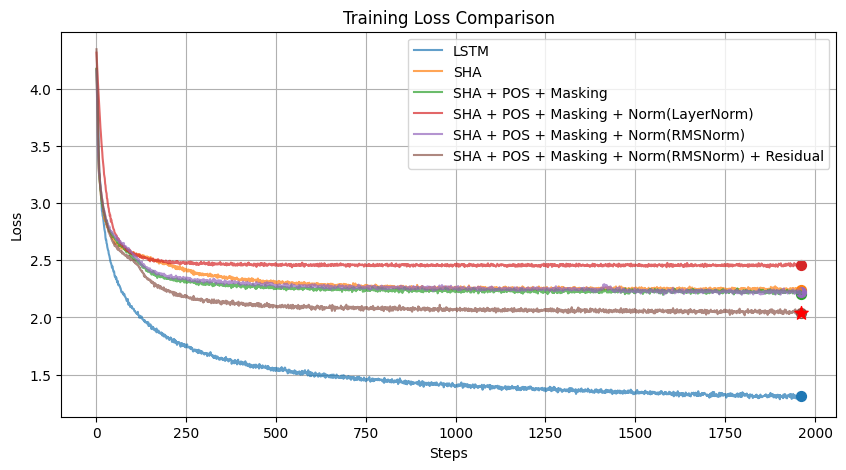

In [57]:
train_and_test("SHA", start_text)

The performance of this simple attention model lags behind the LSTM model. There are several reasons for this:
- Lack of positional encoding, which hinders the model’s ability to understand the sequence order.
- Single-head attention may not capture sufficient complexity in relationships between tokens.
- Basic architecture without residual connections or normalization can limit model performance.

## SHA + Positional Encoding

Unlike LSTM models, attention-based models do not inherently understand the order of tokens. To address this, we introduce positional encoding, which provides the model with information about the sequence order. In this case, we use a learnable positional embedding, similar to how BERT models incorporate positional information.

In [58]:
import torch
import torch.nn.functional as F

class SingleHeadAttention(nn.Module):
    def __init__(self, d_model, seq_length):
        super(SingleHeadAttention, self).__init__()
        self.d_model = d_model
        self.seq_length = seq_length

        self.query = nn.Linear(d_model, d_model, bias=False)
        self.key = nn.Linear(d_model, d_model, bias=False)
        self.value = nn.Linear(d_model, d_model, bias=False)
        self.fc_out = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Scaled dot-product attention
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_model ** 0.5)

        attention_probs = F.softmax(attention_scores, dim=-1)
        attention_output = torch.matmul(attention_probs, V)

        return self.fc_out(attention_output)


# LLaMA Decoder Layer
class LLaMADecoderLayer(nn.Module):
    def __init__(self, embedding_dim, seq_length):
        super(LLaMADecoderLayer, self).__init__()
        self.attention = SingleHeadAttention(embedding_dim, seq_length)

    def forward(self, x):
        attention_output = self.attention(x)
        return attention_output

class LLaMAModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, seq_length):
        super(LLaMAModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.layer = LLaMADecoderLayer(embedding_dim, seq_length)
        self.fc_out = nn.Linear(embedding_dim, vocab_size, bias=False) # lm_head

        # Learnable Positional Embedding
        self.positional_embedding = nn.Embedding(seq_length, embedding_dim)


    def forward(self, idx, targets=None):
        x = self.embedding(idx)

        # Add positional embeddings to input embeddings
        seq_positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)  # Create position indices
        x = x + self.positional_embedding(seq_positions)

        x = self.layer(x)
        logits = self.fc_out(x)

        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            return logits, loss
        return logits, None

Epoch 1/1
Epoch 1, Step 10, Batch 10/1961, Loss: 3.1601
Epoch 1, Step 20, Batch 20/1961, Loss: 2.8907
Epoch 1, Step 30, Batch 30/1961, Loss: 2.7375
Epoch 1, Step 40, Batch 40/1961, Loss: 2.4192
Epoch 1, Step 50, Batch 50/1961, Loss: 0.8280
Epoch 1, Step 60, Batch 60/1961, Loss: 0.1682
Epoch 1, Step 70, Batch 70/1961, Loss: 0.0785
Epoch 1, Step 80, Batch 80/1961, Loss: 0.0599
Epoch 1, Step 90, Batch 90/1961, Loss: 0.0576
Epoch 1, Step 100, Batch 100/1961, Loss: 0.0520
Epoch 1, Step 110, Batch 110/1961, Loss: 0.0508
Epoch 1, Step 120, Batch 120/1961, Loss: 0.0499
Epoch 1, Step 130, Batch 130/1961, Loss: 0.0480
Epoch 1, Step 140, Batch 140/1961, Loss: 0.0482
Epoch 1, Step 150, Batch 150/1961, Loss: 0.0474
Epoch 1, Step 160, Batch 160/1961, Loss: 0.0490
Epoch 1, Step 170, Batch 170/1961, Loss: 0.0475
Epoch 1, Step 180, Batch 180/1961, Loss: 0.0465
Epoch 1, Step 190, Batch 190/1961, Loss: 0.0467
Epoch 1, Step 200, Batch 200/1961, Loss: 0.0449
Epoch 1, Step 210, Batch 210/1961, Loss: 0.0464


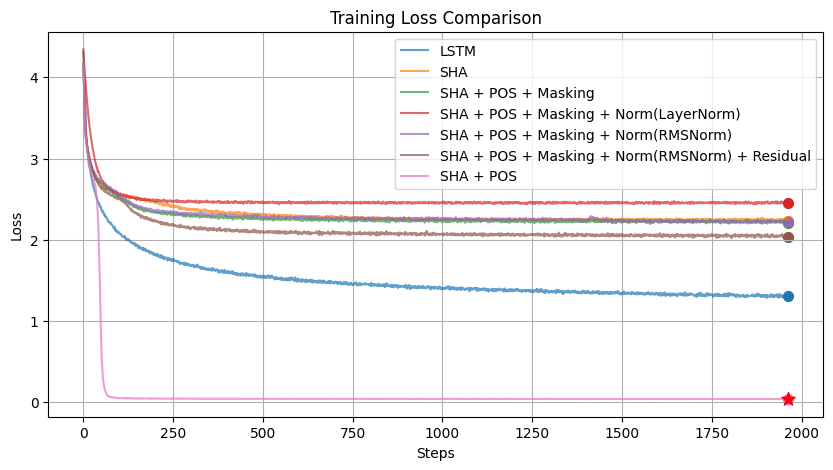

In [59]:
train_and_test("SHA + POS", start_text)

The generated results might look reasonable, but this is due to the model 'cheating.' In self-attention mechanisms without masking, the model sees the entire sequence, including future tokens, during training. As a result, it can predict the next token based on information it shouldn't have access to, leading to unrealistic results. To prevent this, we need to implement 'look-ahead masking.'

In [60]:
# Let's remove the not-masking version
del loss_comparison_dict["SHA + POS"] # no need to compare anymore

## Single-Head-Attention + Masking

Look-ahead masking ensures that when predicting the next token, the model only considers tokens that come before the current position. This prevents the model from 'cheating' by looking ahead at future tokens during the training phase. It's crucial for autoregressive generation in transformer models.

In [61]:
import torch
import torch.nn.functional as F

class SingleHeadAttention(nn.Module):
    def __init__(self, d_model, seq_length):
        super(SingleHeadAttention, self).__init__()
        self.d_model = d_model
        self.seq_length = seq_length

        self.query = nn.Linear(d_model, d_model, bias=False)
        self.key = nn.Linear(d_model, d_model, bias=False)
        self.value = nn.Linear(d_model, d_model, bias=False)
        self.fc_out = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Scaled dot-product attention
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_model ** 0.5)

        # look-ahead masking!
        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == 0, float('-inf'))

        attention_probs = F.softmax(attention_scores, dim=-1)
        attention_output = torch.matmul(attention_probs, V)

        return self.fc_out(attention_output)


# LLaMA Decoder Layer
class LLaMADecoderLayer(nn.Module):
    def __init__(self, embedding_dim, seq_length):
        super(LLaMADecoderLayer, self).__init__()
        self.attention = SingleHeadAttention(embedding_dim, seq_length)

    def forward(self, x, mask):
        attention_output = self.attention(x, mask)
        return attention_output


# LLaMA Model with RoPE and Multi-Layer
class LLaMAModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, seq_length):
        super(LLaMAModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.layer = LLaMADecoderLayer(embedding_dim, seq_length)
        self.fc_out = nn.Linear(embedding_dim, vocab_size, bias=False) # lm_head

        # Learnable Positional Embedding
        self.positional_embedding = nn.Embedding(seq_length, embedding_dim)

    def forward(self, idx, targets=None):
        x = self.embedding(idx)

        # Add positional embeddings to input embeddings
        seq_positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)  # Create position indices
        x = x + self.positional_embedding(seq_positions)

        # Look-Ahead Masking
        seq_length = x.size(1)
        mask = torch.tril(torch.ones(seq_length, seq_length)).to(x.device)

        x = self.layer(x, mask)
        logits = self.fc_out(x)

        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            return logits, loss
        return logits, None

Epoch 1/1
Epoch 1, Step 10, Batch 10/1961, Loss: 3.2491
Epoch 1, Step 20, Batch 20/1961, Loss: 2.9798
Epoch 1, Step 30, Batch 30/1961, Loss: 2.8367
Epoch 1, Step 40, Batch 40/1961, Loss: 2.7416
Epoch 1, Step 50, Batch 50/1961, Loss: 2.7158
Epoch 1, Step 60, Batch 60/1961, Loss: 2.6828
Epoch 1, Step 70, Batch 70/1961, Loss: 2.6664
Epoch 1, Step 80, Batch 80/1961, Loss: 2.6401
Epoch 1, Step 90, Batch 90/1961, Loss: 2.6175
Epoch 1, Step 100, Batch 100/1961, Loss: 2.5952
Epoch 1, Step 110, Batch 110/1961, Loss: 2.5919
Epoch 1, Step 120, Batch 120/1961, Loss: 2.5776
Epoch 1, Step 130, Batch 130/1961, Loss: 2.5563
Epoch 1, Step 140, Batch 140/1961, Loss: 2.5432
Epoch 1, Step 150, Batch 150/1961, Loss: 2.5184
Epoch 1, Step 160, Batch 160/1961, Loss: 2.4894
Epoch 1, Step 170, Batch 170/1961, Loss: 2.4531
Epoch 1, Step 180, Batch 180/1961, Loss: 2.4406
Epoch 1, Step 190, Batch 190/1961, Loss: 2.4173
Epoch 1, Step 200, Batch 200/1961, Loss: 2.3810
Epoch 1, Step 210, Batch 210/1961, Loss: 2.3740


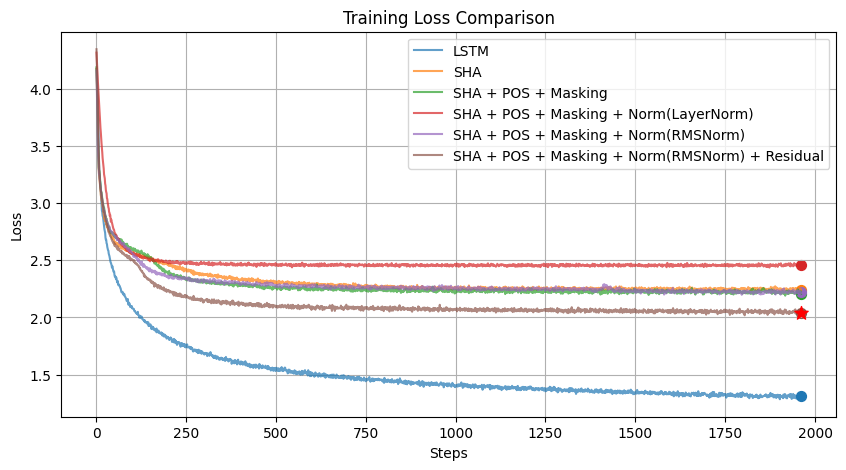

In [62]:
train_and_test("SHA + POS + Masking", start_text)

With look-ahead masking, we obtain more *realistic* performance curves. This method ensures the model no longer has access to future tokens, providing a more challenging, yet authentic, learning task. We now begin to observe the expected loss behavior.

## SHA + POS + Masking + Norm(LayerNorm)

Next, we introduce normalization layers into the model. Layer normalization (LayerNorm) stabilizes the training process by normalizing the output of each layer, preventing issues such as exploding or vanishing gradients. We apply LayerNorm before and after the attention mechanism and the feed-forward layer.

In [63]:
import torch
import torch.nn.functional as F

class SingleHeadAttention(nn.Module):
    def __init__(self, d_model, seq_length):
        super(SingleHeadAttention, self).__init__()
        self.d_model = d_model
        self.seq_length = seq_length

        self.query = nn.Linear(d_model, d_model, bias=False)
        self.key = nn.Linear(d_model, d_model, bias=False)
        self.value = nn.Linear(d_model, d_model, bias=False)
        self.fc_out = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Scaled dot-product attention
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_model ** 0.5)

        # look-ahead masking!
        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == 0, float('-inf'))

        attention_probs = F.softmax(attention_scores, dim=-1)
        attention_output = torch.matmul(attention_probs, V)

        return self.fc_out(attention_output)


# LLaMA Decoder Layer
class LLaMADecoderLayer(nn.Module):
    def __init__(self, embedding_dim, seq_length):
        super(LLaMADecoderLayer, self).__init__()
        self.attention = SingleHeadAttention(embedding_dim, seq_length)
        self.layernorm1 = nn.LayerNorm(embedding_dim) # pre-norm
        self.layernorm2 = nn.LayerNorm(embedding_dim) # post-norm

    def forward(self, x, mask):
        # Pre-Norm
        normed_x = self.layernorm1(x)

        # Attention
        attention_output = self.attention(normed_x, mask)

        # Post-Norm
        normed_x = self.layernorm2(attention_output)

        return x

class LLaMAModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, seq_length):
        super(LLaMAModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.layer = LLaMADecoderLayer(embedding_dim, seq_length)
        self.fc_out = nn.Linear(embedding_dim, vocab_size, bias=False) # lm_head

        # final norm after top-layer
        self.layernorm3 = nn.LayerNorm(embedding_dim) # final-norm

        # Learnable Positional Embedding
        self.positional_embedding = nn.Embedding(seq_length, embedding_dim)

    def forward(self, idx, targets=None):
        x = self.embedding(idx)

        # Add positional embeddings to input embeddings
        seq_positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)  # Create position indices
        x = x + self.positional_embedding(seq_positions)

        # Look-Ahead Masking
        seq_length = x.size(1)
        mask = torch.tril(torch.ones(seq_length, seq_length)).to(x.device)

        x = self.layer(x, mask)

        # Normalization
        x = self.layernorm3(x)

        logits = self.fc_out(x)

        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            return logits, loss
        return logits, None

Epoch 1/1
Epoch 1, Step 10, Batch 10/1961, Loss: 3.8076
Epoch 1, Step 20, Batch 20/1961, Loss: 3.3951
Epoch 1, Step 30, Batch 30/1961, Loss: 3.1158
Epoch 1, Step 40, Batch 40/1961, Loss: 2.9385
Epoch 1, Step 50, Batch 50/1961, Loss: 2.7909
Epoch 1, Step 60, Batch 60/1961, Loss: 2.7081
Epoch 1, Step 70, Batch 70/1961, Loss: 2.6474
Epoch 1, Step 80, Batch 80/1961, Loss: 2.6206
Epoch 1, Step 90, Batch 90/1961, Loss: 2.5907
Epoch 1, Step 100, Batch 100/1961, Loss: 2.5694
Epoch 1, Step 110, Batch 110/1961, Loss: 2.5536
Epoch 1, Step 120, Batch 120/1961, Loss: 2.5386
Epoch 1, Step 130, Batch 130/1961, Loss: 2.5289
Epoch 1, Step 140, Batch 140/1961, Loss: 2.5193
Epoch 1, Step 150, Batch 150/1961, Loss: 2.5159
Epoch 1, Step 160, Batch 160/1961, Loss: 2.4966
Epoch 1, Step 170, Batch 170/1961, Loss: 2.5096
Epoch 1, Step 180, Batch 180/1961, Loss: 2.4848
Epoch 1, Step 190, Batch 190/1961, Loss: 2.4912
Epoch 1, Step 200, Batch 200/1961, Loss: 2.4917
Epoch 1, Step 210, Batch 210/1961, Loss: 2.4977


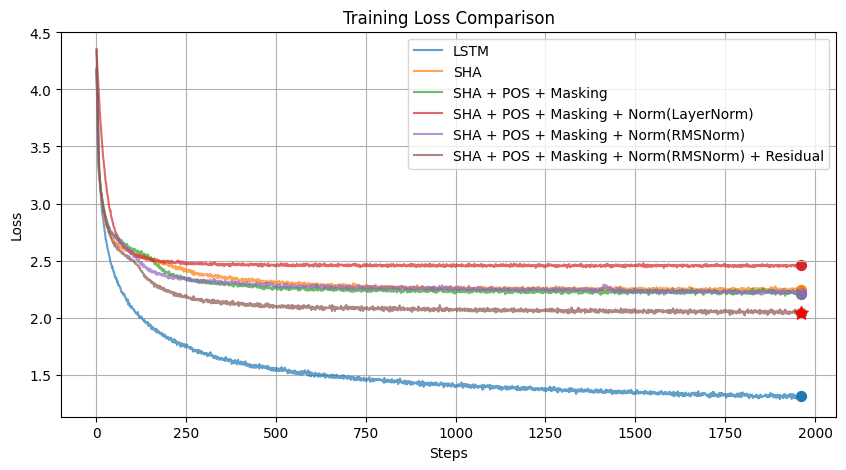

In [64]:
train_and_test("SHA + POS + Masking + Norm(LayerNorm)", start_text)

## SHA + POS + Masking + Norm(RMSNorm)

RMSNorm is a variation of LayerNorm that is more efficient for certain architectures, such as LLaMA. Instead of normalizing across all dimensions, it normalizes only across the root mean square of the dimensions, improving stability in large models. We now replace LayerNorm with RMSNorm for comparison.

In [65]:
import torch
import torch.nn.functional as F

class SingleHeadAttention(nn.Module):
    def __init__(self, d_model, seq_length):
        super(SingleHeadAttention, self).__init__()
        self.d_model = d_model
        self.seq_length = seq_length

        self.query = nn.Linear(d_model, d_model, bias=False)
        self.key = nn.Linear(d_model, d_model, bias=False)
        self.value = nn.Linear(d_model, d_model, bias=False)
        self.fc_out = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Scaled dot-product attention
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_model ** 0.5)

        # look-ahead masking!
        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == 0, float('-inf'))

        attention_probs = F.softmax(attention_scores, dim=-1)
        attention_output = torch.matmul(attention_probs, V)

        return self.fc_out(attention_output)


# Custom RMSNorm to match LLaMA 1 official implementation
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super(RMSNorm, self).__init__()
        self.weight = nn.Parameter(torch.ones(d_model))
        self.eps = eps

    def _norm(self, x):
        # Compute variance and apply reciprocal square root for RMS normalization
        ################## 여기 추가 ##################
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True))
        x = x / (rms + self.eps)
        return x

    def forward(self, x):
        # Convert to float32 for precision, then back to original dtype
        output = self._norm(x.float()).type_as(x)
        return output * self.weight


# LLaMA Decoder Layer
class LLaMADecoderLayer(nn.Module):
    def __init__(self, embedding_dim, seq_length):
        super(LLaMADecoderLayer, self).__init__()
        self.attention = SingleHeadAttention(embedding_dim, seq_length)
        self.rmsnorm1 = RMSNorm(embedding_dim) # pre-norm
        self.rmsnorm2 = RMSNorm(embedding_dim) # post-norm

    def forward(self, x, mask):
        # Pre-Norm
        normed_x = self.rmsnorm1(x)

        # Attention
        attention_output = self.attention(normed_x, mask)

        # Post-Norm
        normed_x = self.rmsnorm2(attention_output)

        return normed_x

class LLaMAModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, seq_length):
        super(LLaMAModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.layer = LLaMADecoderLayer(embedding_dim, seq_length)
        self.fc_out = nn.Linear(embedding_dim, vocab_size, bias=False) # lm_head

        self.rmsnorm_f = RMSNorm(embedding_dim) # final_norm

        # Learnable Positional Embedding
        self.positional_embedding = nn.Embedding(seq_length, embedding_dim)

    def forward(self, idx, targets=None):
        x = self.embedding(idx)

        # Add positional embeddings to input embeddings
        seq_positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)  # Create position indices
        x = x + self.positional_embedding(seq_positions)

        # Look-Ahead Masking
        seq_length = x.size(1)
        mask = torch.tril(torch.ones(seq_length, seq_length)).to(x.device)

        x = self.layer(x, mask)

        # final norm
        x = self.rmsnorm_f(x)

        logits = self.fc_out(x)

        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            return logits, loss
        return logits, None

Epoch 1/1
Epoch 1, Step 10, Batch 10/1961, Loss: 3.0917
Epoch 1, Step 20, Batch 20/1961, Loss: 2.8455
Epoch 1, Step 30, Batch 30/1961, Loss: 2.7355
Epoch 1, Step 40, Batch 40/1961, Loss: 2.6703
Epoch 1, Step 50, Batch 50/1961, Loss: 2.6350
Epoch 1, Step 60, Batch 60/1961, Loss: 2.5977
Epoch 1, Step 70, Batch 70/1961, Loss: 2.5425
Epoch 1, Step 80, Batch 80/1961, Loss: 2.4909
Epoch 1, Step 90, Batch 90/1961, Loss: 2.4493
Epoch 1, Step 100, Batch 100/1961, Loss: 2.3998
Epoch 1, Step 110, Batch 110/1961, Loss: 2.3753
Epoch 1, Step 120, Batch 120/1961, Loss: 2.3575
Epoch 1, Step 130, Batch 130/1961, Loss: 2.3259
Epoch 1, Step 140, Batch 140/1961, Loss: 2.3074
Epoch 1, Step 150, Batch 150/1961, Loss: 2.2980
Epoch 1, Step 160, Batch 160/1961, Loss: 2.2926
Epoch 1, Step 170, Batch 170/1961, Loss: 2.3055
Epoch 1, Step 180, Batch 180/1961, Loss: 2.2842
Epoch 1, Step 190, Batch 190/1961, Loss: 2.2794
Epoch 1, Step 200, Batch 200/1961, Loss: 2.2875
Epoch 1, Step 210, Batch 210/1961, Loss: 2.2627


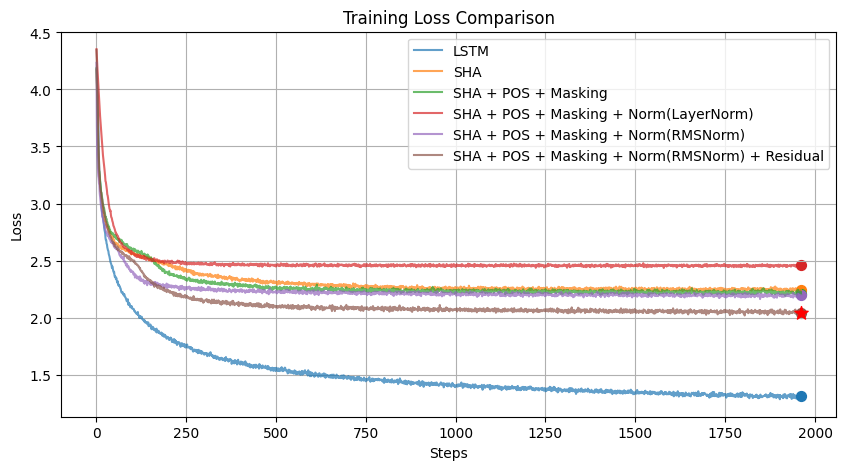

In [66]:
train_and_test("SHA + POS + Masking + Norm(RMSNorm)", start_text)

While RMSNorm hasn't shown a large improvement at this stage, it is expected to have a more significant impact on larger models.

Its effectiveness becomes more pronounced as the model size and complexity increase. We'll see its benefits in later stages with more advanced architectures.

## SHA + POS + Masking + Norm(RMSNorm) + Residual

In [67]:
import torch
import torch.nn.functional as F

class SingleHeadAttention(nn.Module):
    def __init__(self, d_model, seq_length):
        super(SingleHeadAttention, self).__init__()
        self.d_model = d_model
        self.seq_length = seq_length

        self.query = nn.Linear(d_model, d_model, bias=False)
        self.key = nn.Linear(d_model, d_model, bias=False)
        self.value = nn.Linear(d_model, d_model, bias=False)
        self.fc_out = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Scaled dot-product attention
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_model ** 0.5)

        # look-ahead masking!
        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == 0, float('-inf'))

        attention_probs = F.softmax(attention_scores, dim=-1)
        attention_output = torch.matmul(attention_probs, V)

        return self.fc_out(attention_output)


# Custom RMSNorm to match LLaMA 1 official implementation
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super(RMSNorm, self).__init__()
        self.weight = nn.Parameter(torch.ones(d_model))
        self.eps = eps

    def _norm(self, x):
        # Compute variance and apply reciprocal square root for RMS normalization

        ################## 여기 추가 ##################
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True))
        x = x / (rms + self.eps)
        return x

    def forward(self, x):
        # Convert to float32 for precision, then back to original dtype
        output = self._norm(x.float()).type_as(x)
        return output * self.weight


# LLaMA Decoder Layer
class LLaMADecoderLayer(nn.Module):
    def __init__(self, embedding_dim, seq_length):
        super(LLaMADecoderLayer, self).__init__()
        self.attention = SingleHeadAttention(embedding_dim, seq_length)
        self.rmsnorm1 = RMSNorm(embedding_dim) # pre-norm
        self.rmsnorm2 = RMSNorm(embedding_dim) # post-norm

    def forward(self, x, mask):

        ################## 여기 추가 ##################
        # Pre-Norm
        normed_x = self.rmsnorm1(x)

        # Attention
        attention_output = self.attention(normed_x, mask)

        # Residual Connection
        x = x + attention_output

        # Post-Norm
        normed_x = self.rmsnorm2(x)

        # Residual Connection
        x = x + normed_x

        return x

class LLaMAModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, seq_length):
        super(LLaMAModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.layer = LLaMADecoderLayer(embedding_dim, seq_length)
        self.fc_out = nn.Linear(embedding_dim, vocab_size, bias=False) # lm_head

        self.rmsnorm_f = RMSNorm(embedding_dim) # final_norm

        # Learnable Positional Embedding
        self.positional_embedding = nn.Embedding(seq_length, embedding_dim)

    def forward(self, idx, targets=None):
        x = self.embedding(idx)

        # Add positional embeddings to input embeddings
        seq_positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)  # Create position indices
        x = x + self.positional_embedding(seq_positions)

        # Look-Ahead Masking
        seq_length = x.size(1)
        mask = torch.tril(torch.ones(seq_length, seq_length)).to(x.device)

        x = self.layer(x, mask)

        # final norm
        x = self.rmsnorm_f(x)

        logits = self.fc_out(x)

        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            return logits, loss
        return logits, None


Epoch 1/1
Epoch 1, Step 10, Batch 10/1961, Loss: 3.2466
Epoch 1, Step 20, Batch 20/1961, Loss: 2.9767
Epoch 1, Step 30, Batch 30/1961, Loss: 2.8086
Epoch 1, Step 40, Batch 40/1961, Loss: 2.7250
Epoch 1, Step 50, Batch 50/1961, Loss: 2.6570
Epoch 1, Step 60, Batch 60/1961, Loss: 2.6175
Epoch 1, Step 70, Batch 70/1961, Loss: 2.5647
Epoch 1, Step 80, Batch 80/1961, Loss: 2.5649
Epoch 1, Step 90, Batch 90/1961, Loss: 2.5306
Epoch 1, Step 100, Batch 100/1961, Loss: 2.5139
Epoch 1, Step 110, Batch 110/1961, Loss: 2.4851
Epoch 1, Step 120, Batch 120/1961, Loss: 2.4415
Epoch 1, Step 130, Batch 130/1961, Loss: 2.4137
Epoch 1, Step 140, Batch 140/1961, Loss: 2.3445
Epoch 1, Step 150, Batch 150/1961, Loss: 2.3155
Epoch 1, Step 160, Batch 160/1961, Loss: 2.2886
Epoch 1, Step 170, Batch 170/1961, Loss: 2.2641
Epoch 1, Step 180, Batch 180/1961, Loss: 2.2374
Epoch 1, Step 190, Batch 190/1961, Loss: 2.2198
Epoch 1, Step 200, Batch 200/1961, Loss: 2.2127
Epoch 1, Step 210, Batch 210/1961, Loss: 2.1813


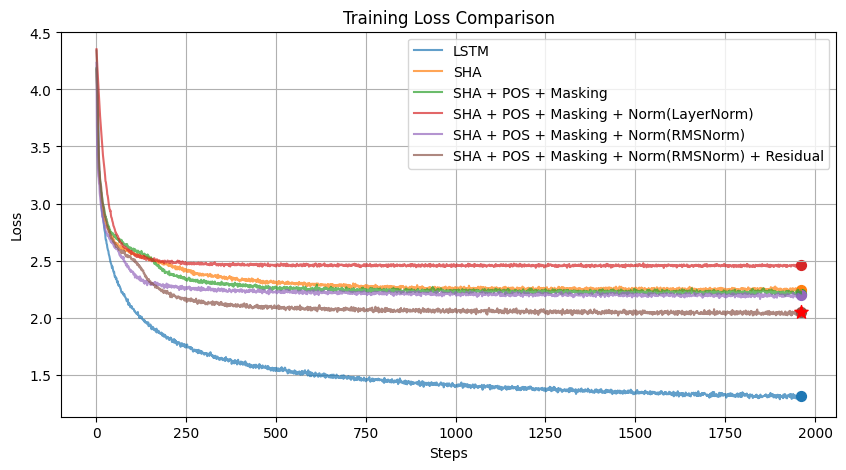

In [68]:
train_and_test("SHA + POS + Masking + Norm(RMSNorm) + Residual", start_text)

Residual connections help prevent the degradation of information as it passes through multiple layers.

By adding the input directly to the output of certain layers (e.g., attention and feed-forward layers), we ensure that important information isn't lost during the transformation process.
